In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/weather_population.csv")

Overview


In [4]:
df.shape

(26, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         26 non-null     object 
 1   country_x    26 non-null     object 
 2   temperature  26 non-null     float64
 3   humidity     26 non-null     int64  
 4   wind_speed   26 non-null     float64
 5   weather      26 non-null     object 
 6   rank         22 non-null     float64
 7   country_y    22 non-null     object 
 8   population   22 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 2.0+ KB


In [6]:
df.describe()

,temperature,humidity,wind_speed,rank,population
count,26.000000,26.000000,26.000000,22.000000,2.200000e+01
mean,24.978462,62.653846,2.976154,45.136364,1.449336e+07
std,6.428824,21.040803,1.849952,41.653097,1.077499e+07
min,11.540000,17.000000,0.450000,1.000000,3.560908e+06
25%,19.800000,53.000000,1.685000,12.500000,5.336450e+06
50%,26.330000,71.000000,2.680000,30.000000,1.157842e+07
75%,29.672500,77.000000,3.972500,75.500000,1.969736e+07
max,38.470000,86.000000,7.150000,132.000000,4.191386e+07


Data quality check


In [12]:
df.nunique()

city           25
country_x      20
temperature    25
humidity       19
wind_speed     21
weather         3
rank           25
country_y      20
population     25
dtype: int64

In [13]:
df.isnull().sum()

city           0
country_x      0
temperature    0
humidity       0
wind_speed     0
weather        0
rank           0
country_y      0
population     0
dtype: int64

In [14]:
df[df["population"].isna()][["city"]]

,city


In [15]:
df.duplicated().sum()

np.int64(0)

Exploring data


In [16]:
df["weather"].value_counts()


weather
Clouds    16
Clear      7
Rain       2
Name: count, dtype: int64

In [17]:
top_5_hottest_cities = df.sort_values(by="temperature",ascending=False).head(5)
top_5_hottest_cities[["city","temperature"]]

,city,temperature
10,New Delhi,38.47
21,Cairo,35.23
22,Dubai,31.39
3,Singapore,31.07
11,Mumbai,30.58


In [18]:
top_5_hummid_cities = df.sort_values(by="humidity",ascending=False).head(5)
top_5_hummid_cities[["city","humidity"]]

,city,humidity
1,Ho Chi Minh City,86
7,Seoul,86
4,Jakarta,85
3,Singapore,84
20,São Paulo,84


In [19]:
average_temperature = df["temperature"].mean()
print(round(float(average_temperature), 2))

24.65


In [23]:
average_humidity = df["humidity"].mean()
print(round(float(average_humidity), 2))

62.04


In [20]:
df.nlargest(5,"population")[["city", "population"]]

,city,population
4,Jakarta,41913860
6,Tokyo,33412512
10,New Delhi,30222405
9,Shanghai,29558908
21,Cairo,25566102


Visualization


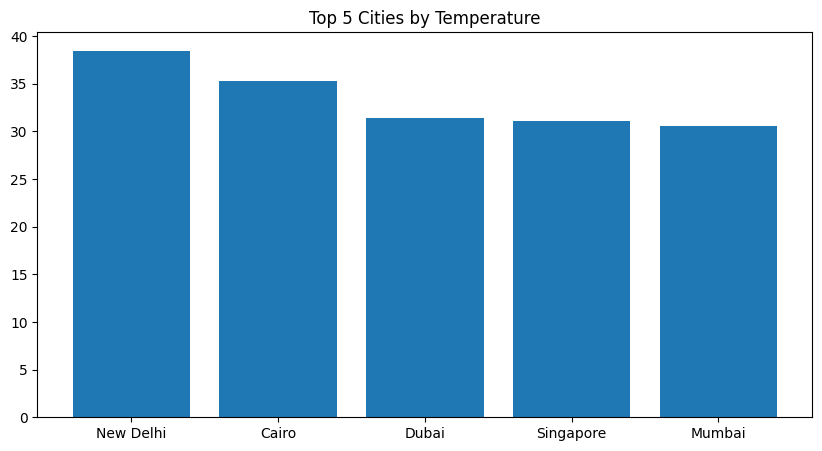

In [21]:
top_5_cities_by_temperature = df.sort_values(by="temperature",ascending=False).head(5)
plt.figure(figsize=(10,5))
plt.bar(top_5_cities_by_temperature["city"], top_5_cities_by_temperature["temperature"])
plt.title("Top 5 Cities by Temperature")
plt.show()

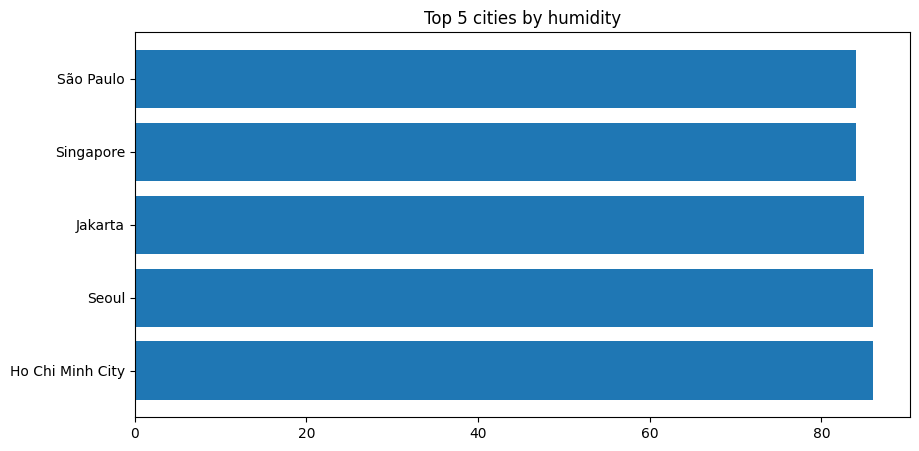

In [22]:
top_5_cities_by_humidity = df.sort_values(by="humidity",ascending=False).head(5)
plt.figure(figsize=(10,5))
plt.barh(top_5_cities_by_humidity["city"], top_5_cities_by_humidity["humidity"])
plt.title("Top 5 cities by humidity")
plt.show()

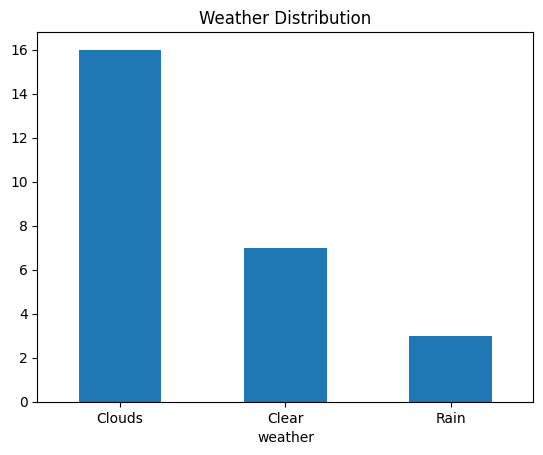

In [40]:

df["weather"].value_counts().plot(kind="bar")
plt.xticks(rotation=0)
plt.title("Weather Distribution")
plt.show()

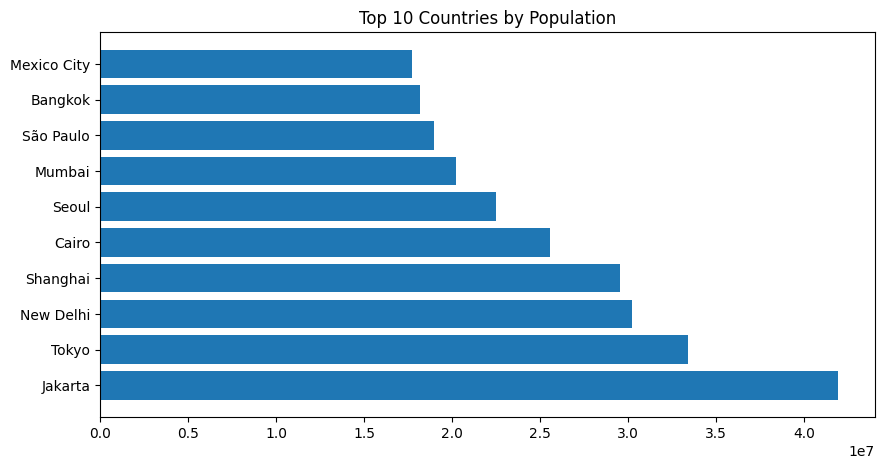

In [39]:
top_population = df.sort_values(by="population",ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(top_population["city"], top_population["population"])
plt.title("Top 10 Countries by Population")
plt.xticks(rotation=0)
plt.show()

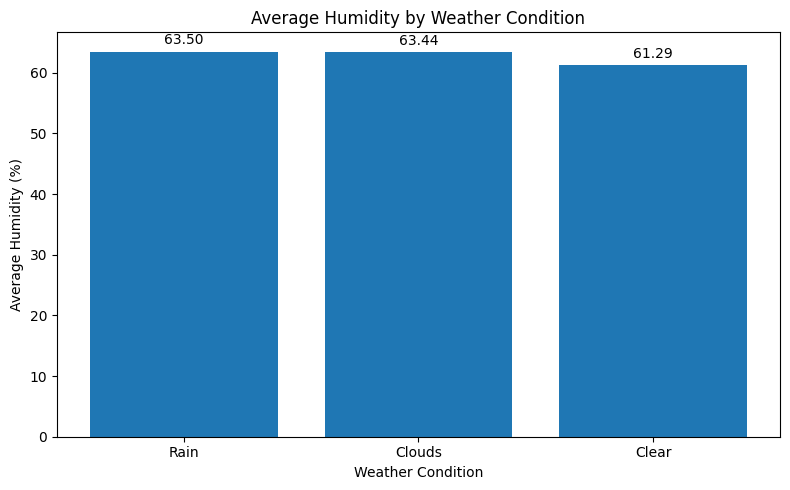

In [9]:
humidity_weather = df.groupby("weather")["humidity"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(humidity_weather.index, humidity_weather.values)
ax.bar_label(bars, fmt="%.2f", padding = 3)
ax.set_title("Average Humidity by Weather Condition")
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Average Humidity (%)")
plt.tight_layout()
